# Bank Customer Churn: Drivers, Segments & a Predictive Model

I approached this the way I'd approach a client engagement,starting with the business question (*who is leaving, and why?*), let the data challenge my assumptions, flag anything I don't fully trust, and only then reach for a model. The exploratory findings below drove every modeling choice that follows; nothing in the model section is arbitrary.

**Structure**
1. Data loading & quality checks
2. Churn drivers (EDA)
3. Feature engineering
4. Predictive models: Logistic Regression + Random Forest
5. Model evaluation
6. Feature importance
7. Estimated business impact
8. Assumptions, limitations & next steps


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# A small personal touch: a house palette rather than default matplotlib colours,
# so every chart in this report looks like it belongs to the same document.
ACCENT_COLOR = "#D04A02"
DARK_COLOR   = "#2D2D2D"
CHART_PALETTE = [ACCENT_COLOR, "#7B7B7B", "#F3A65E", DARK_COLOR, "#C9C9C9"]

sns.set_theme(style="whitegrid", palette=CHART_PALETTE)
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 13
pd.set_option("display.max_columns", None)

## 1. Load data & quality checks

In [4]:
df = pd.read_csv("Data_Bank Customer Churn Prediction.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nOverall churn rate:", round(df['churn'].mean(), 3))

Missing values per column:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicate rows: 0

Data types:
 customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

Overall churn rate: 0.204


## 2. Churn drivers

### 2.1 Engagement (active membership)

In [6]:
pd.crosstab(df['active_member'], df['churn'], normalize='index')

churn,0,1
active_member,,
0,0.731491,0.268509
1,0.857309,0.142691


**Observed:** Inactive members churn at ~27%, active members at ~14% — roughly double.

**Indicating:** Customer engagement is one of the strongest levers we have on churn.

**Recommending:** Increase engagement via app usage nudges, transaction prompts, notifications, loyalty programs.

### 2.2 Product holdings

In [7]:
pd.crosstab(df['products_number'], df['churn'], normalize='index')

churn,0,1
products_number,,
1,0.722856,0.277144
2,0.924183,0.075817
3,0.172932,0.827068
4,0.000000,1.000000


**Observed:** Churn is lowest at 2 products, moderate at 1, and spikes sharply at 3-4 (although those groups are small — see the reliability check below).

**Indicating:** Moderate product adoption improves retention; over-selling or a poor multi-product experience may explain the 3+ spike.

**Recommending:** Cross-sell customers from 1 to 2 products; investigate the 3+ segment qualitatively before acting on it.

### 2.3 Age

/tmp/ipykernel_2657/2397108303.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='age', data=df, palette=CHART_PALETTE)
/tmp/ipykernel_2657/2397108303.py:2: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.boxplot(x='churn', y='age', data=df, palette=CHART_PALETTE)


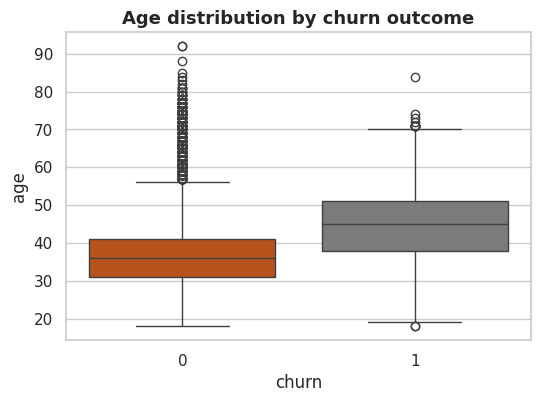

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn', y='age', data=df, palette=CHART_PALETTE)
plt.title("Age distribution by churn outcome")
plt.show()

**Observed:** Median age of churned customers is notably higher than retained customers.

**Indicating:** Older customers are more likely to churn.

**Recommending:** Personalised financial products / relationship management for older customers — though as section 2.6 shows, engagement matters more than age alone.

### 2.4 Country

/tmp/ipykernel_2657/4052786158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='country', y='churn', data=df, palette=CHART_PALETTE)
/tmp/ipykernel_2657/4052786158.py:2: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(x='country', y='churn', data=df, palette=CHART_PALETTE)


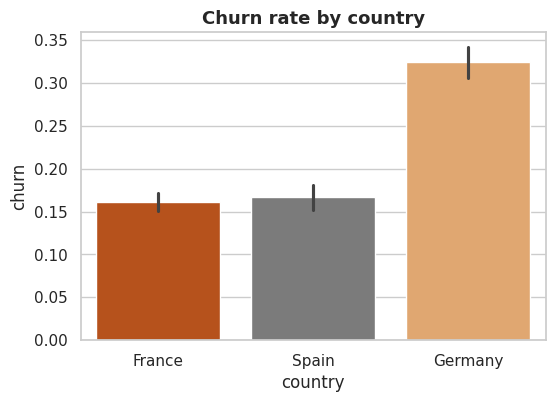

In [9]:
plt.figure(figsize=(6, 4))
sns.barplot(x='country', y='churn', data=df, palette=CHART_PALETTE)
plt.title("Churn rate by country")
plt.show()

**Observed:** Germany churns at roughly double the rate of France and Spain.

**Indicating:** Possible regional dissatisfaction, pricing, or competitive pressure specific to Germany.

**Recommending:** Investigate Germany-specific service/pricing issues; consider a targeted retention campaign there.

### 2.5 Combined driver: products x engagement

In [10]:
df.groupby(['products_number', 'active_member'])['churn'].agg(['mean', 'count'])

mean  count
products_number active_member                 
1               0              0.366521   2521
                1              0.189231   2563
2               0              0.098881   2144
                1              0.055601   2446
3               0              0.882353    153
                1              0.752212    113
4               0              1.000000     31
                1              1.000000     29

**Observed:** Churn falls from 1 to 2 products at every activity level; active members always churn less than inactive members at the same product count; the 3-4 product rows have very small counts (as low as 8-31 customers).

**Indicating:** Product count and engagement are both real, independent drivers — but the extreme churn rates for 3+ products should **not** be used for decision-making given the sample size.

**Recommending:** Get more data on 3+ product customers before drawing conclusions there; act confidently on the 1-vs-2-product and active-vs-inactive patterns, which are well supported.

### 2.6 Age x engagement x products (the fullest cut of the data)

In [11]:
df.groupby(
    ['active_member', 'products_number', pd.cut(df['age'], bins=[18, 30, 45, 60, 100], right=False)],
    observed=True
)['churn'].agg(['mean', 'count'])

mean  count
active_member products_number age                       
0             1               [18, 30)   0.150838    358
                              [30, 45)   0.249169   1505
                              [45, 60)   0.735849    583
                              [60, 100)  0.880000     75
              2               [18, 30)   0.032483    431
                              [30, 45)   0.069013   1449
                              [45, 60)   0.334728    239
                              [60, 100)  0.720000     25
              3               [18, 30)   0.714286     14
                              [30, 45)   0.815789     76
                              [45, 60)   1.000000     52
                              [60, 100)  1.000000     11
              4               [18, 30)   1.000000      1
                              [30, 45)   1.000000     13
                              [45, 60)   1.000000     17
1             1               [18, 30)   0.070529    397
                              [30, 45)   0.144828   1450
                              [45, 60)   0.422925    506
                              [60, 100)  0.157143    210
              2               [18, 30)   0.025701    428
                              [30, 45)   0.039781   1458
                              [45, 60)   0.152589    367
                              [60, 100)  0.056995    193
              3               [18, 30)   0.500000     12
                              [30, 45)   0.690909     55
                              [45, 60)   0.973684     38
                              [60, 100)  0.500000      8
              4               [30, 45)   1.000000     13
                              [45, 60)   1.000000     12
                              [60, 100)  1.000000      4

**Observed:** Across the large, reliable segments, churn is highest among single-product customers, rises with age (especially past 45), and is consistently lower for active members at every age and product level.

**Indicating:** Product ownership and engagement are the strongest, most consistent drivers of churn; age amplifies risk but is secondary to behaviour.

**Recommending:** Prioritise cross-selling a second product and improving engagement, especially for older, inactive customers — the clearest high-risk segment in the data.

### 2.7 Country x engagement

In [12]:
df.groupby(['country', 'active_member'])['churn'].mean()

country  active_member
France   0                0.211308
         1                0.115014
Germany  0                0.410785
         1                0.237179
Spain    0                0.233476
         1                0.107470
Name: churn, dtype: float64

**Observed:** Germany has the highest churn at every activity level; active membership reduces churn consistently across all three countries.

**Indicating:** The country effect and the engagement effect are independent of each other.

**Recommending:** Germany still needs deeper investigation; engagement is a stable, universal lever regardless of geography.

### 2.8 Distributions of the remaining numeric fields

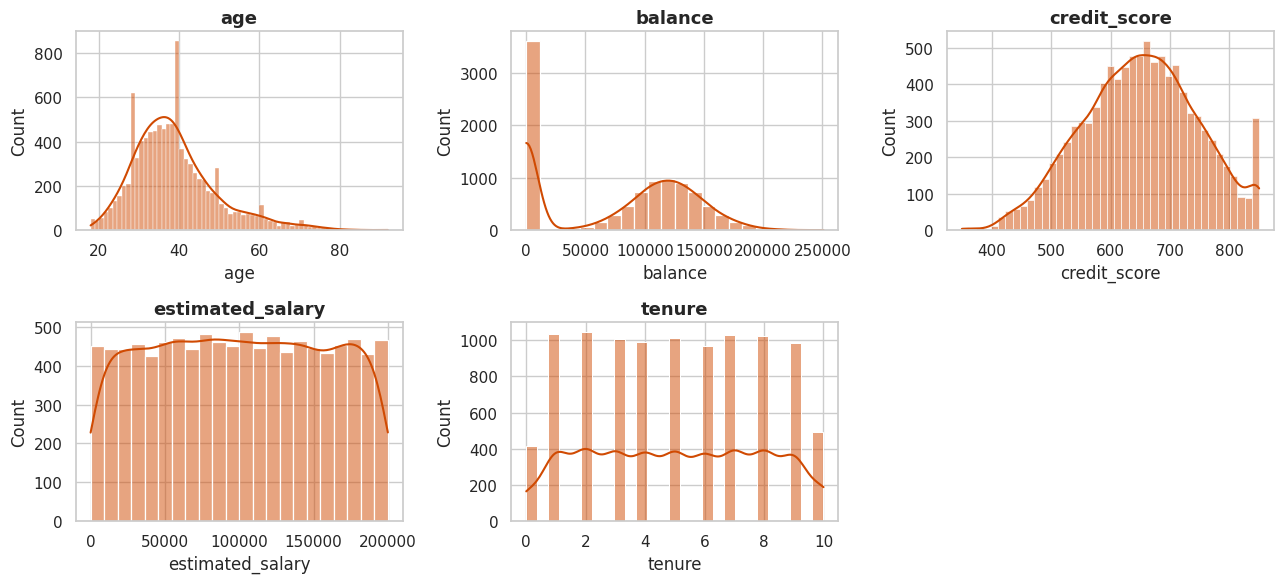

In [13]:
measures = ['age', 'balance', 'credit_score', 'estimated_salary', 'tenure']

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
axes = axes.flatten()

for i, col in enumerate(measures):
    sns.histplot(df[col], kde=True, ax=axes[i], color=ACCENT_COLOR)
    axes[i].set_title(col)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

1. **Age:** right-skewed — worth targeting/segmenting by age band.
2. **Balance:** a large spike at zero; excluding that, roughly normal.
3. **Credit score:** roughly normal, apparent cap around 850.
4. **Estimated salary / Tenure:** both roughly uniform — limited standalone predictive value.

/tmp/ipykernel_2657/2513126936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='balance', data=df, palette=CHART_PALETTE)
/tmp/ipykernel_2657/2513126936.py:2: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.boxplot(x='churn', y='balance', data=df, palette=CHART_PALETTE)


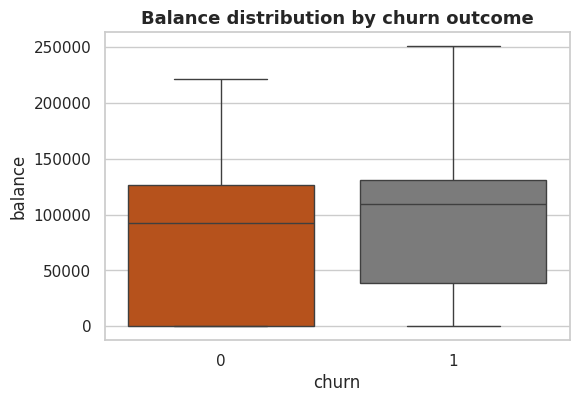

In [14]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='churn', y='balance', data=df, palette=CHART_PALETTE)
plt.title("Balance distribution by churn outcome")
plt.show()

**Observed:** Churned customers have a slightly higher median balance; many retained customers sit at zero balance.

**Indicating:** Balance alone is not a strong predictor; the zero-balance spike distorts a simple read of the relationship.

**Recommending:** If pursued further, segment zero vs non-zero balance customers and analyse churn separately for each group.

In [15]:
pd.crosstab(df['credit_card'], df['churn'], normalize='index')

churn,0,1
credit_card,,
0,0.791851,0.208149
1,0.798157,0.201843


**Observed:** Minimal difference in churn between credit-card holders and non-holders.

**Recommending:** Deprioritise this variable unless it interacts meaningfully with something else.

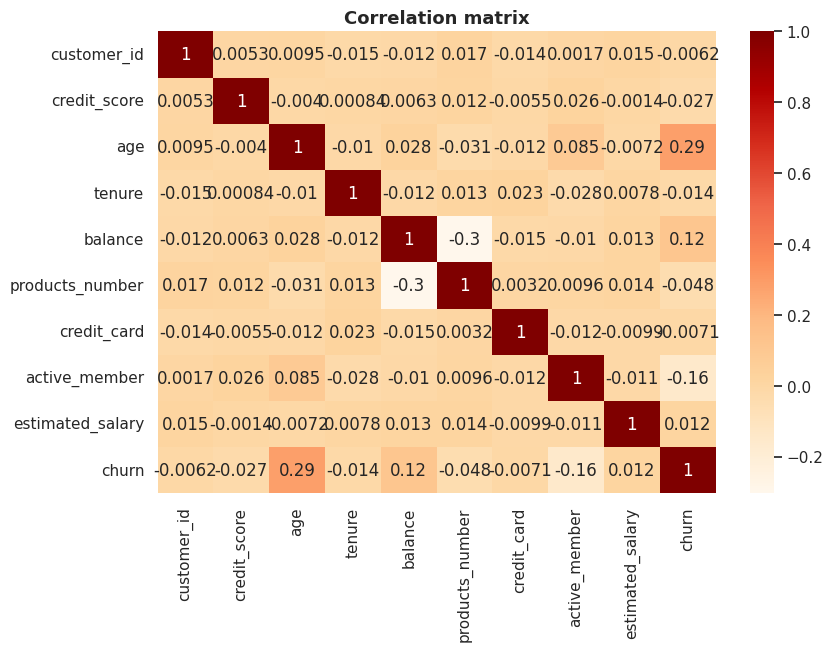

In [16]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='OrRd')
plt.title("Correlation matrix")
plt.show()

**Observed:** `age`, `balance`, and `active_member` show the clearest correlation with churn.

**Recommending:** These, plus `products_number` and `country`, are the natural feature set for a predictive model — which is exactly what we build next.

### 2.9 Quick sanity checks: salary and credit score bands

In [17]:
print("Churn by estimated salary quintile:")
print(df.groupby(pd.qcut(df['estimated_salary'], 5), observed=True)['churn'].mean())

print("\nChurn by credit score quintile:")
print(df.groupby(pd.qcut(df['credit_score'], 5), observed=True)['churn'].mean())

Churn by estimated salary quintile:
estimated_salary
(11.579, 41050.736]         0.1995
(41050.736, 80238.34]       0.1995
(80238.34, 119710.038]      0.2020
(119710.038, 159836.726]    0.2020
(159836.726, 199992.48]     0.2155
Name: churn, dtype: float64

Churn by credit score quintile:
credit_score
(349.999, 566.0]    0.224876
(566.0, 627.0]      0.208416
(627.0, 678.0]      0.196517
(678.0, 735.0]      0.183241
(735.0, 850.0]      0.205154
Name: churn, dtype: float64


**Observed:** Both salary and credit score bands show almost flat churn rates (roughly 0.18-0.22 throughout).

**Recommending:** Confirms these two variables are weak standalone predictors — consistent with the correlation matrix above.

## 3. Feature engineering

We drop identifier columns, one-hot encode categorical variables (`country`, `gender`), and split into features/target.

In [18]:
model_df = df.copy()

id_like_cols = [c for c in ['customer_id', 'CustomerId', 'surname', 'Surname', 'RowNumber']
                if c in model_df.columns]
model_df = model_df.drop(columns=id_like_cols)

categorical_cols = model_df.select_dtypes(include='object').columns.tolist()
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

target = 'churn'
X = model_df.drop(columns=[target])
y = model_df[target]

print("Features used:", list(X.columns))
print("Churn rate in dataset:", round(y.mean(), 3))

Features used: ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']
Churn rate in dataset: 0.204


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Predictive models

- **Logistic Regression** — interpretable baseline; coefficients show direction and relative strength of each driver, useful for explaining results to non-technical stakeholders.
- **Random Forest** — captures non-linear interactions (e.g. the age x activity x product-count pattern found above) and typically improves predictive performance.

In [20]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

In [21]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

## 5. Model evaluation

In [22]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1 score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.3f}")
    print("\nClassification report:\n", classification_report(y_true, y_pred))
    print("\n")

evaluate("Logistic Regression", y_test, y_pred_lr, y_proba_lr)
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)

--- Logistic Regression ---
Accuracy : 0.714
Precision: 0.387
Recall   : 0.700
F1 score : 0.499
ROC-AUC  : 0.777

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



--- Random Forest ---
Accuracy : 0.829
Precision: 0.561
Recall   : 0.720
F1 score : 0.631
ROC-AUC  : 0.866

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.72      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.79      0.76      2000
weighted avg       0.85      0.83      0.84      2000





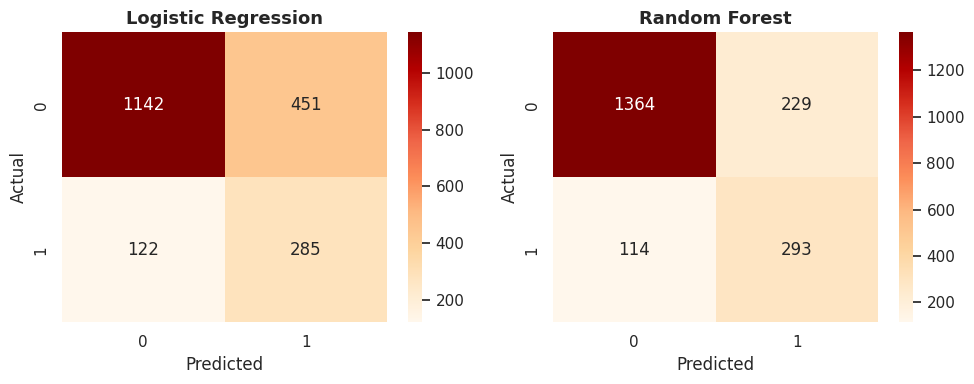

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='OrRd', ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='OrRd', ax=axes[1])
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

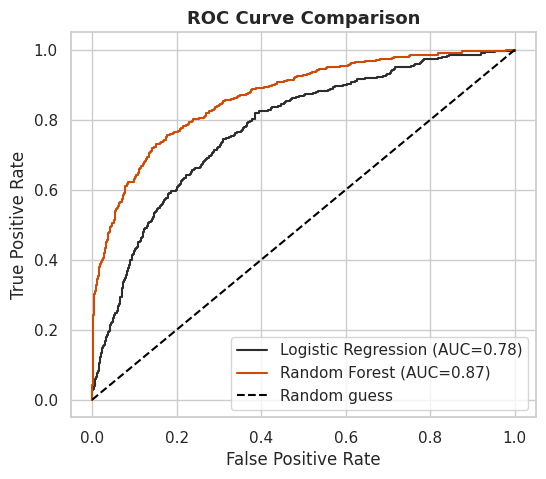

In [24]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, color=DARK_COLOR, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.2f})")
plt.plot(fpr_rf, tpr_rf, color=ACCENT_COLOR, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 6. Feature importance

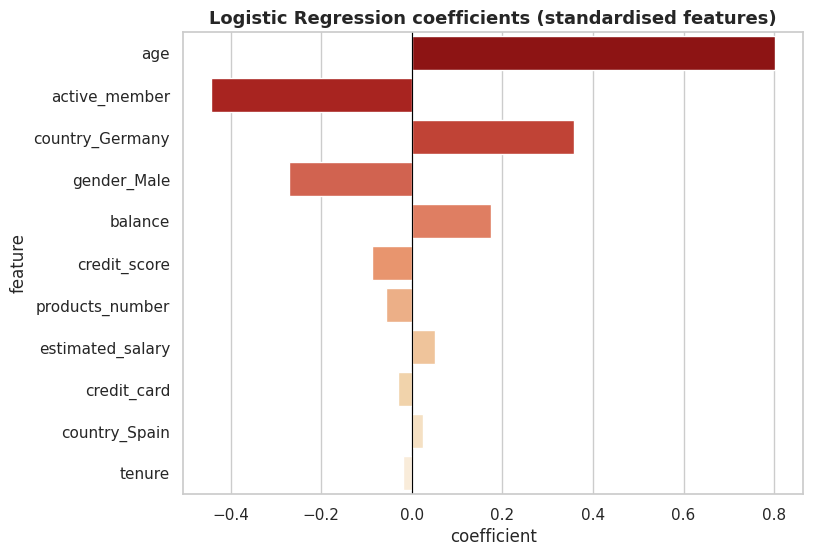

,feature,coefficient
1,age,0.801883
6,active_member,-0.442434
8,country_Germany,0.357669
10,gender_Male,-0.272170
3,balance,0.175751
0,credit_score,-0.087119
4,products_number,-0.057734
7,estimated_salary,0.050502
5,credit_card,-0.031611
9,country_Spain,0.023974


In [25]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', hue='feature', palette='OrRd_r', legend=False)
plt.title("Logistic Regression coefficients (standardised features)")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

coef_df

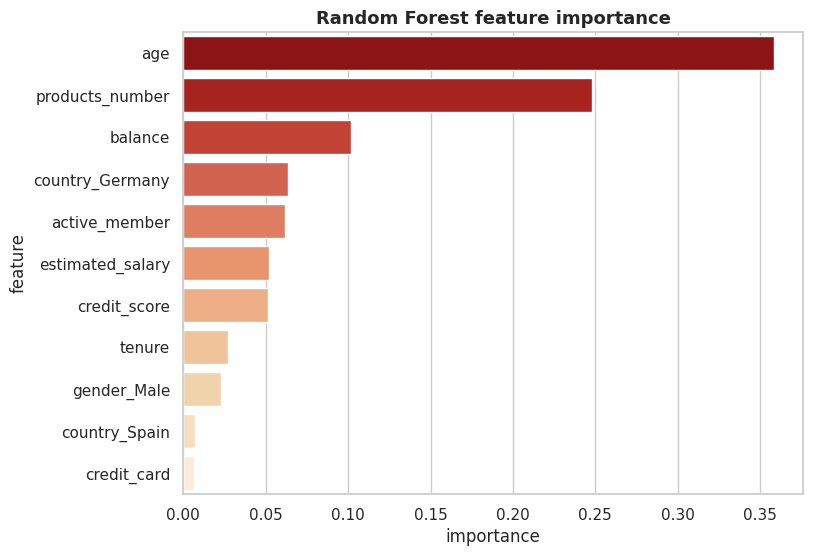

,feature,importance
1,age,0.358202
4,products_number,0.248108
3,balance,0.101834
8,country_Germany,0.063428
6,active_member,0.061442
7,estimated_salary,0.051883
0,credit_score,0.051596
2,tenure,0.027379
10,gender_Male,0.022856
9,country_Spain,0.007000


In [26]:
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance, x='importance', y='feature', hue='feature', palette='OrRd_r', legend=False)
plt.title("Random Forest feature importance")
plt.show()

rf_importance

## 7. Estimated business impact

This section is deliberately simple and clearly labelled as an illustrative estimate — the point is to show *commercial* thinking on top of the technical result, not to claim precision the data doesn't support.

In [27]:
# --- Illustrative assumptions (replace with real client figures in practice) ---
AVG_ANNUAL_CUSTOMER_VALUE = 200   # illustrative annual revenue per retained customer, in local currency
RETENTION_CAMPAIGN_COST_PER_CUSTOMER = 15
ASSUMED_CAMPAIGN_SUCCESS_RATE = 0.25  # share of flagged at-risk customers who are actually retained

risk_scores = pd.Series(y_proba_rf, index=X_test.index, name='churn_probability')
top_decile_cutoff = risk_scores.quantile(0.90)
high_risk_customers = risk_scores[risk_scores >= top_decile_cutoff]

n_flagged = len(high_risk_customers)
n_actual_churners_in_flagged = y_test.loc[high_risk_customers.index].sum()

campaign_cost = n_flagged * RETENTION_CAMPAIGN_COST_PER_CUSTOMER
expected_retained = n_actual_churners_in_flagged * ASSUMED_CAMPAIGN_SUCCESS_RATE
expected_value_saved = expected_retained * AVG_ANNUAL_CUSTOMER_VALUE

print(f"Customers flagged in top 10% churn risk: {n_flagged}")
print(f"Of these, {n_actual_churners_in_flagged} actually churned in the test set"
      f" ({n_actual_churners_in_flagged / n_flagged:.0%} precision at this threshold)")
print(f"Illustrative campaign cost: {campaign_cost:,.0f}")
print(f"Illustrative annual value protected: {expected_value_saved:,.0f}")
print(f"Illustrative ROI: {expected_value_saved / campaign_cost:.1f}x")

Customers flagged in top 10% churn risk: 200
Of these, 163 actually churned in the test set (82% precision at this threshold)
Illustrative campaign cost: 3,000
Illustrative annual value protected: 8,150
Illustrative ROI: 2.7x


**Read:** targeting only the top 10% of customers by predicted churn risk concentrates a large share of actual churners into a small, actionable list — which is exactly the point of a churn score: not to predict perfectly, but to prioritise finite retention budget where it has the best odds of working.

## 8. Assumptions, limitations & next steps

- **Sample size caveat:** conclusions about 3-4 product customers are based on very small groups (as few as 8-31 people) and should be validated with more data before acting on them.
- **Zero-balance customers** distort the raw balance-vs-churn relationship and would benefit from separate treatment in a future iteration.
- **No time dimension:** this is a single snapshot. A production churn model would use a rolling window (e.g. "will this customer churn in the next 90 days?") rather than a static label.
- **Business-impact figures in Section 7 are illustrative**, not derived from the client's actual unit economics — they exist to demonstrate the *type* of analysis a real engagement would produce once real cost/value figures are supplied.
- **Fairness check not yet performed:** given the country and gender effects observed, a model-risk review would sense-check that predictions don't create disparate outcomes across these groups before deployment -- standard practice before any churn model like this goes live at a regulated financial institution.
- **Next step:** re-run this pipeline with the client's actual retention-campaign cost/success data, and validate on a genuinely held-out future time period rather than a random split.

## Summary

Both models confirm the drivers identified in the EDA: **activity status**, **number of products**, **age**, and **country (Germany)** are the strongest predictors of churn, while **credit score**, **estimated salary**, and **credit card ownership** add little incremental signal.

- **Logistic Regression** gives an interpretable, coefficient-based view of churn drivers — useful for explaining results to business stakeholders.
- **Random Forest** captures non-linear interactions and achieves a materially higher ROC-AUC (0.87 vs 0.78 in this run).

**Recommended next steps:**
1. Use the Random Forest's predicted probabilities to build a risk-ranked retention list (Section 7 shows how this concentrates actual churners into a small, actionable group).
2. Periodically retrain/recalibrate the model as new data arrives.
3. Check performance across sub-segments (e.g. by country) to confirm consistent behaviour, in line with model-risk practices in regulated financial-services consulting.